## Group Project 1
### Ivy Salazar

In [1]:
import numpy as np

data = np.loadtxt("RCV1.txt", skiprows=28)

time = data[:,0]
rv = data[:,1]
rv_err = data[:,2]

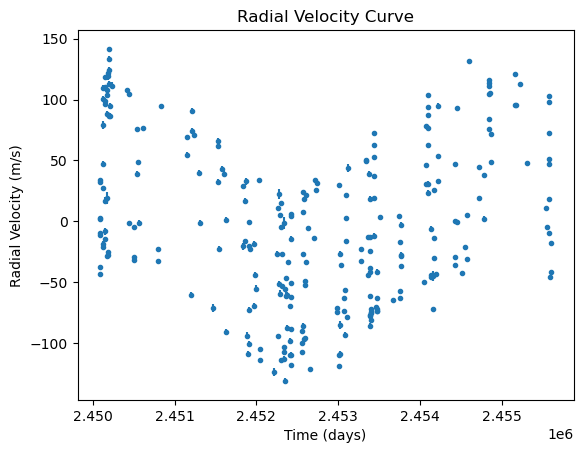

In [2]:
import matplotlib.pyplot as plt

plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=3)

plt.xlabel("Time (days)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Curve")

plt.show()

In [3]:
def rv_model(t, K, P, phi, offset):
    return K * np.sin(2*np.pi*t/P + phi) + offset

In [4]:
from scipy.optimize import curve_fit

initial_guess = [130, 14.6, 0, np.mean(rv)]

params, covariance = curve_fit(
    rv_model,
    time,
    rv,
    p0=initial_guess,
    sigma=rv_err,
    absolute_sigma=True
)

K_fit, P_fit, phi_fit, offset_fit = params

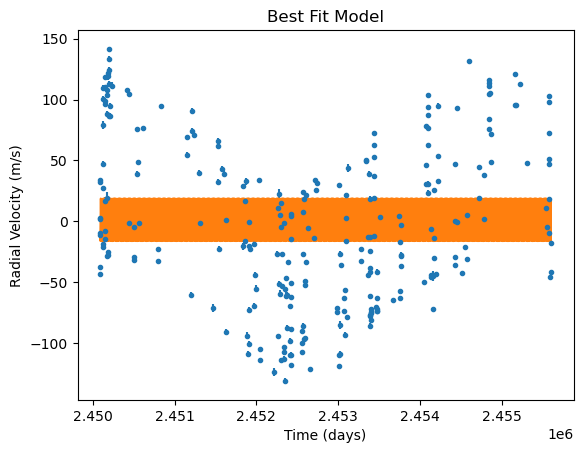

In [5]:
t_fit = np.linspace(min(time), max(time), 5000)
rv_fit = rv_model(t_fit, K_fit, P_fit, phi_fit, offset_fit)

plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=3)
plt.plot(t_fit, rv_fit)

plt.xlabel("Time (days)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Best Fit Model")

plt.show()


In [6]:
residuals = rv - rv_model(time, K_fit, P_fit, phi_fit, offset_fit)

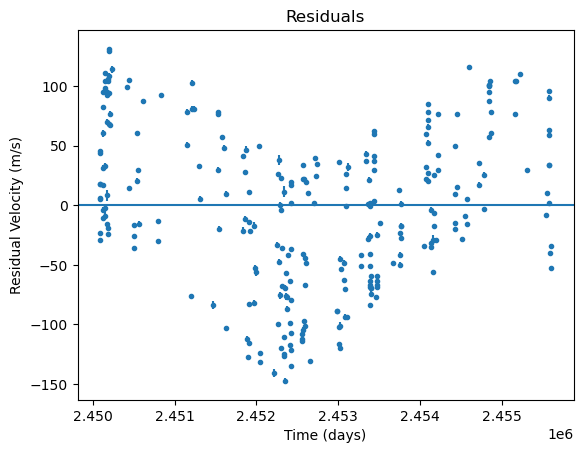

In [7]:
plt.errorbar(time, residuals, yerr=rv_err, fmt='o', markersize=3)

plt.axhline(0)

plt.xlabel("Time (days)")
plt.ylabel("Residual Velocity (m/s)")
plt.title("Residuals")

plt.show()

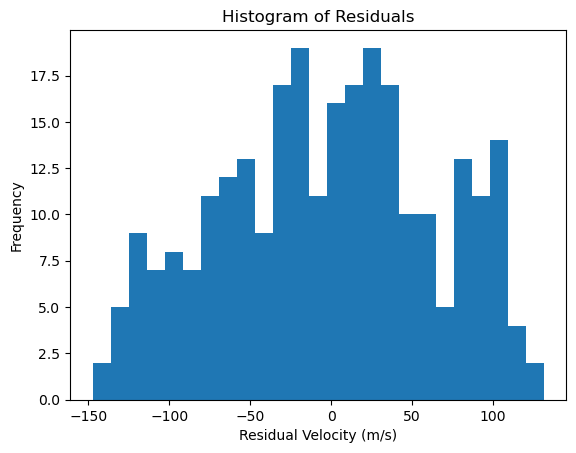

In [8]:
plt.hist(residuals, bins=25)

plt.xlabel("Residual Velocity (m/s)")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

plt.show()


In [9]:
M_star = 0.95

M_planet = (K_fit/28.4) * (P_fit/365)**(1/3) * (M_star)**(2/3)

print("Planet mass (Jupiter masses):", M_planet)

Planet mass (Jupiter masses): 0.20382252838161063
